# Chapter 4: Building Models with Distance Metrics and Nearest Neighbors

## 📋 Summary

This chapter explores K-Nearest Neighbors (KNN), one of the simplest yet most intuitive ML algorithms. KNN is a **lazy learner** — it stores the entire training set and makes predictions by finding the k most similar training examples at inference time.

The chapter begins with the mathematical foundations of **distance metrics** (Euclidean, Manhattan, Minkowski, cosine), then walks through building KNN classifiers and regressors, hyperparameter tuning with grid search, and evaluating model performance. Special attention is given to the impact of feature scaling on distance-based models.

---

## 🧠 Theoretical Explanation

### Distance Metrics
KNN relies entirely on measuring distance between points. Common metrics:

- **Euclidean distance** (p=2): `d = sqrt(Σ(xi - yi)²)` — straight-line distance
- **Manhattan distance** (p=1): `d = Σ|xi - yi|` — sum of absolute differences
- **Minkowski distance**: generalizes both: `d = (Σ|xi - yi|^p)^(1/p)`
- **Cosine similarity**: measures angle between vectors — useful for text

### KNN Algorithm
Given a new point x:
1. Compute distance from x to every training point
2. Select the k training points with smallest distance
3. **Classification**: return the majority class among the k neighbors
4. **Regression**: return the mean target value among the k neighbors

### Choosing k
- **Small k**: Low bias, high variance (overfitting). Decision boundary is jagged.
- **Large k**: High bias, low variance (underfitting). Decision boundary is smooth.
- Rule of thumb: Start with `k = sqrt(n)`, then tune with cross-validation.

### Why Scaling Matters
If one feature ranges from 0–1000 and another from 0–1, the first dominates the distance calculation. Always standardize features before KNN.

### Complexity
- Training: O(1) — just stores the data
- Prediction: O(n·d) — must compare to all n training points across d dimensions
- KD-trees and ball trees speed up inference for low-dimensional data


## 4.1 Understanding Distance Metrics

In [1]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity

# Two sample points
a = np.array([[1, 2, 3]])
b = np.array([[4, 6, 8]])

print('Euclidean distance:', euclidean_distances(a, b)[0][0])
print('Manhattan distance:', manhattan_distances(a, b)[0][0])
print('Cosine similarity:', cosine_similarity(a, b)[0][0])

# Manual Minkowski
def minkowski(x, y, p):
    return np.sum(np.abs(x - y)**p) ** (1/p)

print('\nMinkowski p=1 (Manhattan):', minkowski(a[0], b[0], 1))
print('Minkowski p=2 (Euclidean):', minkowski(a[0], b[0], 2))
print('Minkowski p=3:', minkowski(a[0], b[0], 3))

Euclidean distance: 7.0710678118654755
Manhattan distance: 12.0
Cosine similarity: 0.9925833339709303

Minkowski p=1 (Manhattan): 12.0
Minkowski p=2 (Euclidean): 7.0710678118654755
Minkowski p=3: 5.999999999999999


## 4.2 Building a KNN Classifier

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# KNN pipeline with scaling
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
print(f'KNN (k=5) accuracy: {knn_pipeline.score(X_test, y_test):.3f}')

KNN (k=5) accuracy: 1.000


## 4.3 Comparing Distance Metrics

In [3]:
from sklearn.model_selection import cross_val_score

iris = load_iris()
X, y = iris.data, iris.target

metrics = ['euclidean', 'manhattan', 'minkowski', 'chebyshev']

for metric in metrics:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5, metric=metric))
    ])
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'{metric:12s}: {score:.3f}')

euclidean   : 0.960
manhattan   : 0.947
minkowski   : 0.960
chebyshev   : 0.933


## 4.4 Hyperparameter Tuning for KNN

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(1, 21),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)

print('Best params:', grid.best_params_)
print('Best score:', grid.best_score_)

Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 6, 'knn__weights': 'uniform'}
Best score: 0.9666666666666668


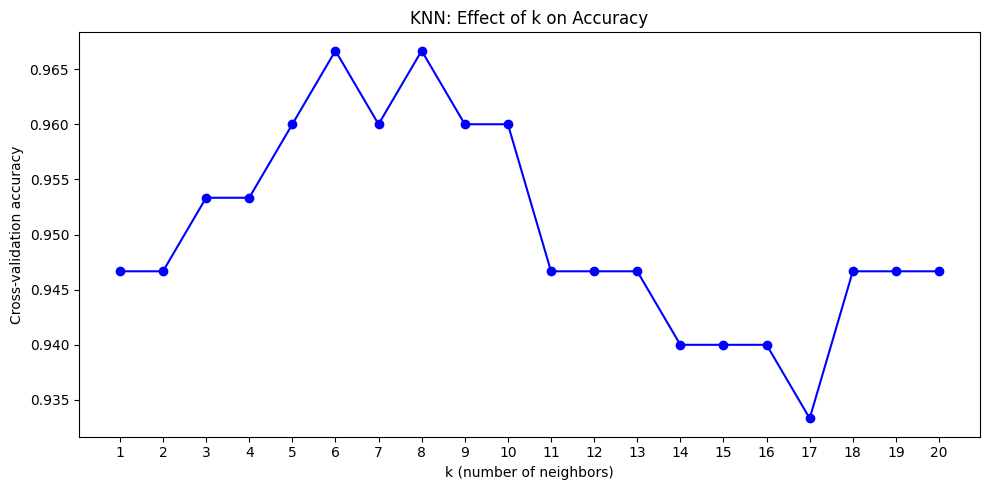

In [5]:
# Plot k vs accuracy
k_values = range(1, 21)
scores = []

for k in k_values:
    pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=k))])
    score = cross_val_score(pipe, X, y, cv=5).mean()
    scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_values, scores, 'bo-')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Cross-validation accuracy')
plt.title('KNN: Effect of k on Accuracy')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

## 4.5 Evaluating KNN Performance

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



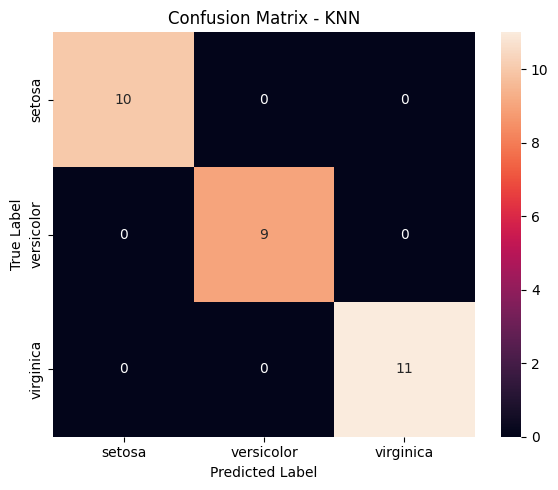

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

best_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

print(classification_report(y_test, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - KNN')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

## 🔑 Key Takeaways

- KNN is a **lazy learner** — no training occurs; prediction uses the entire training set.
- **Feature scaling is mandatory** — distance metrics are dominated by features with large ranges.
- **k is the most important hyperparameter** — small k overfits, large k underfits.
- Weighted KNN (`weights='distance'`) gives closer neighbors more influence, often improving accuracy.
- KNN is slow at prediction time for large datasets — consider tree-based algorithms for scale.
- Distance metric choice matters — use cross-validation to select the best metric.
